In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from hough_sam.constants import FRAMES_DIR, SEG_RESULTS_DIR, FIGURES_DIR, CHECKPOINTS_DIR, LABELS_FILE


Mounted at /content/drive


In [ ]:
!pip uninstall -y opencv-python opencv-contrib-python
!pip install opencv-contrib-python

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 10.5 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import torch
import torchvision
from PIL import Image
from collections import deque

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

# Load SAM2
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

!mkdir -p ./checkpoints/
!wget -P ./checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 10.9 MB/s eta 0:00:00
  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-0cns4p1w
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-0cns4p1w
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.4 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=sam_2-1.0-cp312-cp312-linux_x86_64.whl size=505252 sha256=952ca34973324b6fc528f3ff5e81828216dadd63331b4c215605b6c613f24ee9
  Stored in dire

In [ ]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))


In [ ]:
def sam2_point_prompt_single_frame(predictor, video_dir: str, ann_frame_idx: int, points: np.ndarray, labels: np.ndarray, obj_id: int = 1):
    """
    Follows your exact example style: init_state -> add_new_points_or_box.
    Returns: mask_bool (H,W)
    """
    inference_state = predictor.init_state(video_path=video_dir)

    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=obj_id,
        points=points.astype(np.float32),
        labels=labels.astype(np.int32),
    )

    # pick the mask for obj_id (usually only one here)
    mask_bool = None
    for i, oid in enumerate(out_obj_ids):
        if int(oid) == int(obj_id):
            mask_bool = (out_mask_logits[i] > 0.0).detach().cpu().numpy().squeeze()
            break

    if mask_bool is None:
        # fallback: first output
        mask_bool = (out_mask_logits[0] > 0.0).detach().cpu().numpy().squeeze()

    return mask_bool

def sam2_box_prompt_single_frame(predictor, video_dir: str, ann_frame_idx: int, box_xyxy: np.ndarray, obj_id: int = 1):
    """
    Same flow but pass box=... and omit points/labels.
    Returns: mask_bool (H,W)
    """
    inference_state = predictor.init_state(video_path=video_dir)

    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=obj_id,
        box=box_xyxy.astype(np.float32),
    )

    mask_bool = None
    for i, oid in enumerate(out_obj_ids):
        if int(oid) == int(obj_id):
            mask_bool = (out_mask_logits[i] > 0.0).detach().cpu().numpy().squeeze()
            break

    if mask_bool is None:
        mask_bool = (out_mask_logits[0] > 0.0).detach().cpu().numpy().squeeze()

    return mask_bool

In [ ]:
def make_default_point_prompt(H: int, W: int):
    # 3 positive points near center + 1 negative point near corner
    pts = np.array([
        [0.50 * W, 0.50 * H],
        [0.55 * W, 0.50 * H],
        [0.50 * W, 0.55 * H],
        [0.10 * W, 0.10 * H],  # negative
    ], dtype=np.float32)
    lbl = np.array([1, 1, 1, 0], dtype=np.int32)
    return pts, lbl

def make_default_box_prompt(H: int, W: int):
    # centered box
    return np.array([0.35 * W, 0.35 * H, 0.65 * W, 0.65 * H], dtype=np.float32)

In [ ]:
from sam2.build_sam import build_sam2_video_predictor
#load model
sam2_checkpoint = "./checkpoints/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

sam2_video_predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device="cpu")

In [ ]:
# file paths to three good cases
base_path = FRAMES_DIR
result_path = SEG_RESULTS_DIR

cases = ["case_2000_50fps", "case_2025_50fps", "case_2030_50fps"]
frames = ["0448", "0157", "0215"]


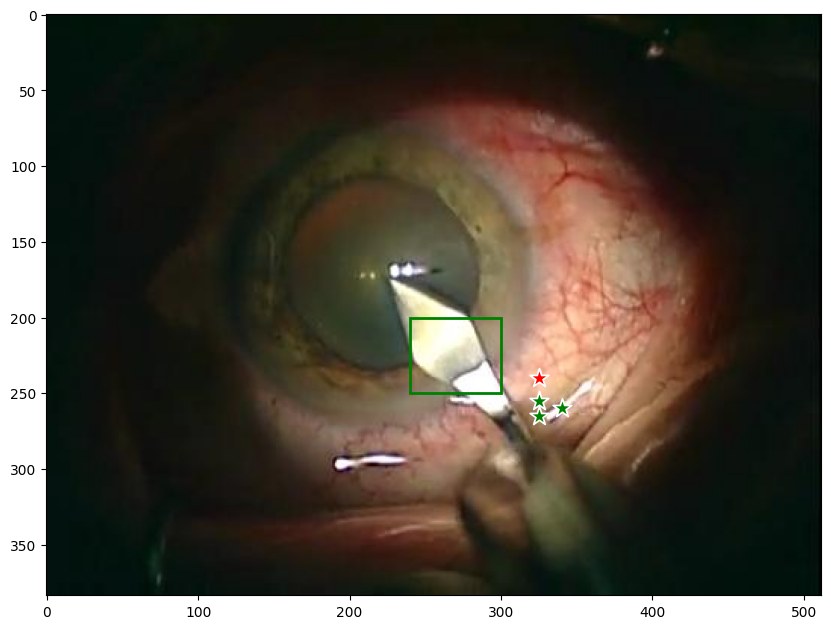

In [ ]:
#plot image and show points
img_path = FRAMES_DIR / "case_2000_50fps" / "0448.jpeg"
img_rgb = np.array(Image.open(img_path).convert("RGB"))
H, W, _ = img_rgb.shape

points, labels = make_default_point_prompt(H, W)
box_xyxy = make_default_box_prompt(H, W)

points = np.array([[325, 255], [325, 265], [340, 260], [325, 240]])
box_xyxy=np.array([240, 200, 300, 250])
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img_rgb)
show_points(points, labels, ax)
show_box(box_xyxy, ax)

frame loading (JPEG): 100%|██████████| 500/500 [00:12<00:00, 38.81it/s]
/usr/local/lib/python3.12/dist-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/usr/local/lib/python3.12/dist-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
frame loading (JPEG): 100%|██████████| 500/500 [00:13<00:00, 38.24it/s]


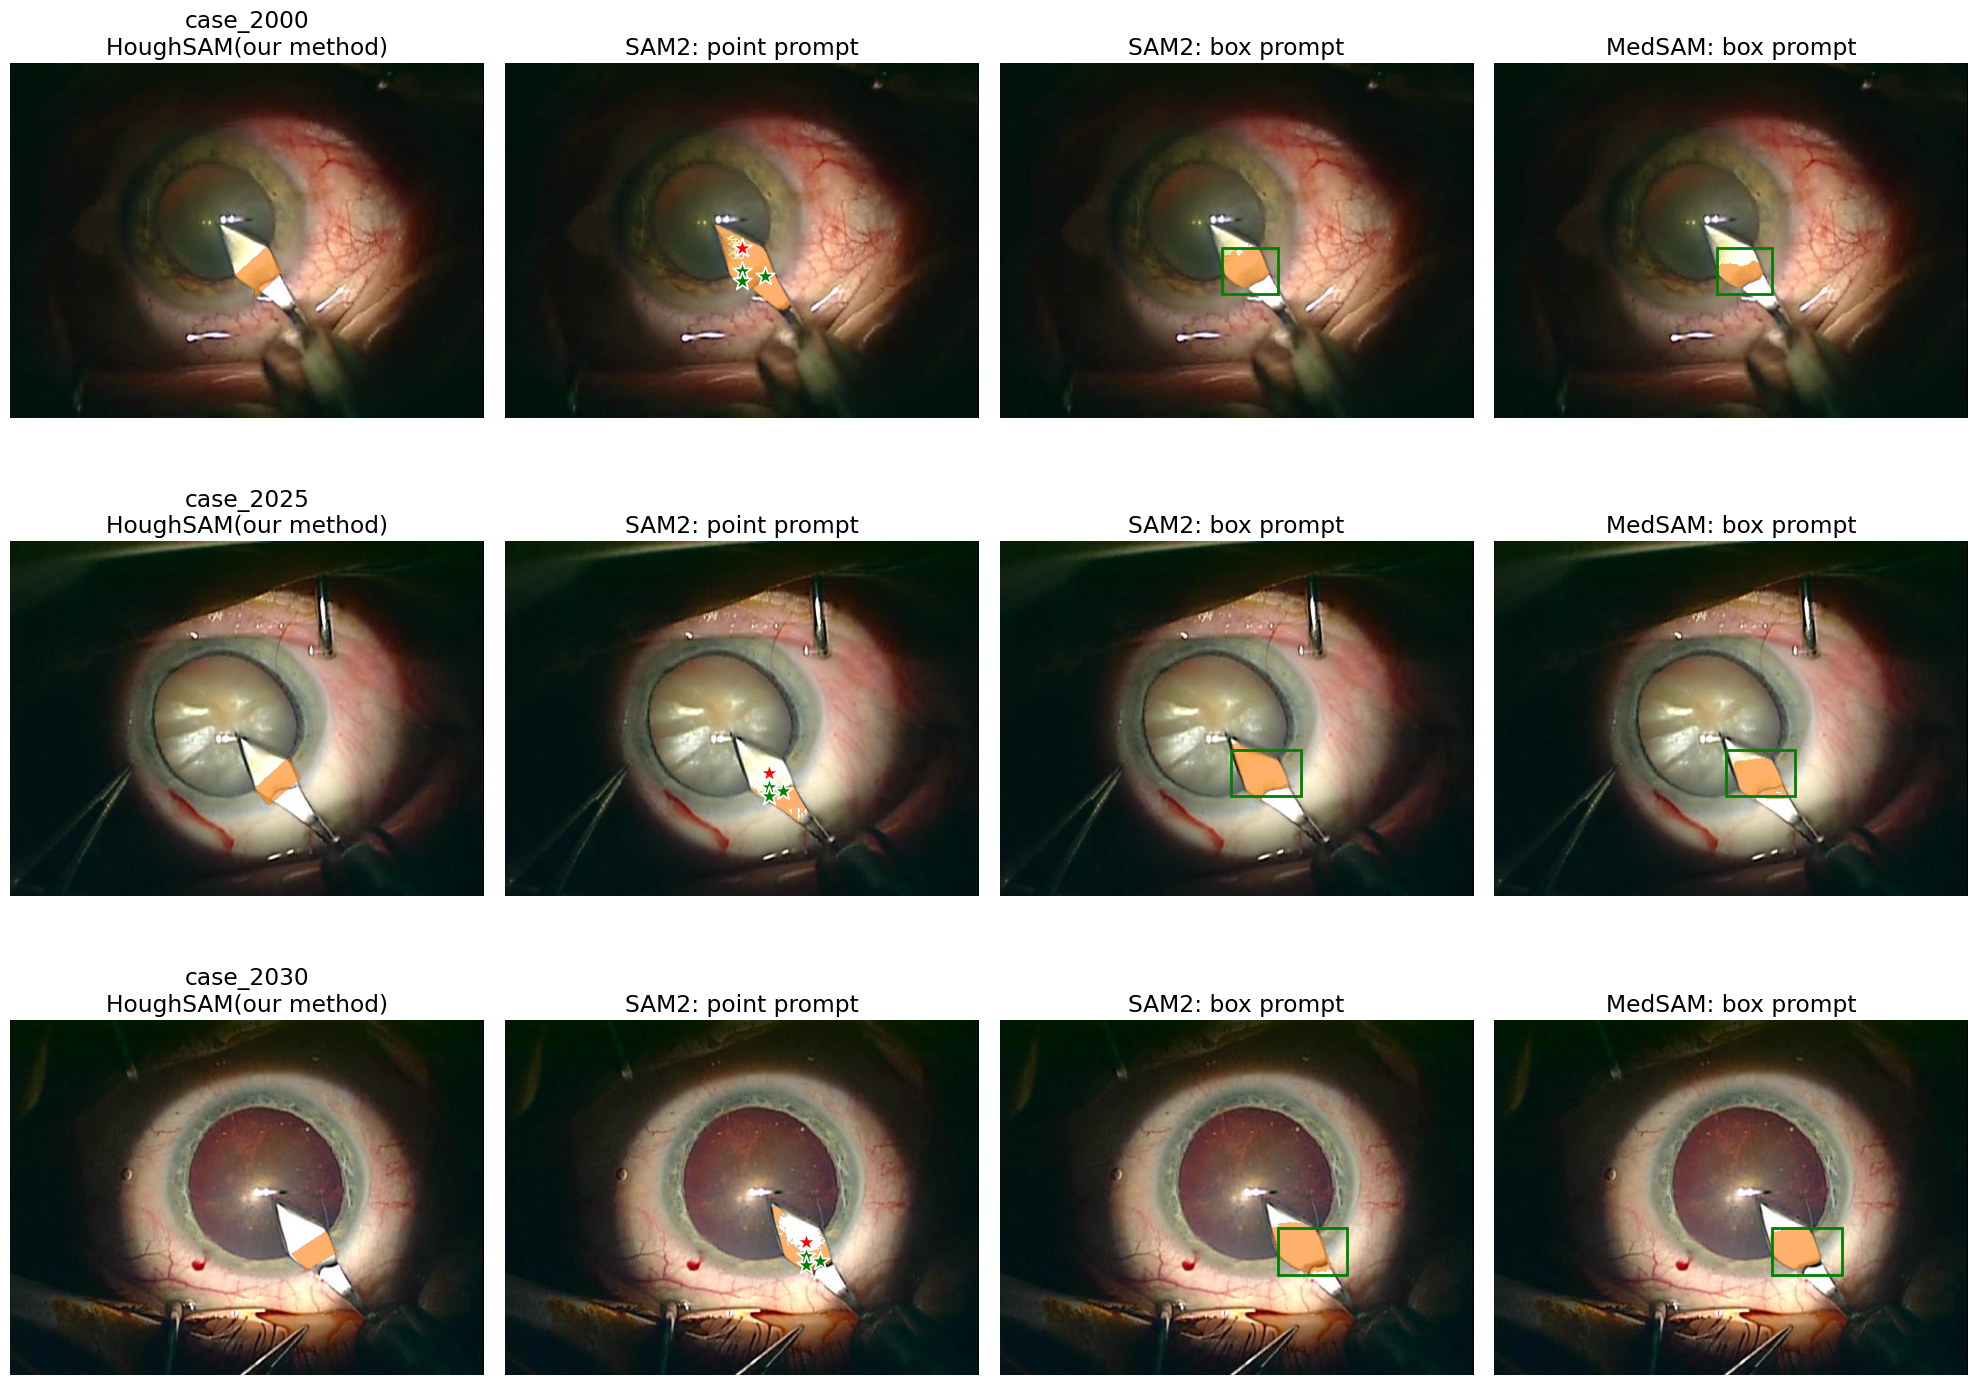

In [ ]:
pairs = list(zip(cases, frames))
n = len(pairs)
point_prompts = [np.array([[256, 225], [256, 235], [281, 230], [256, 200]]),
                 np.array([[285, 265], [285, 275], [300, 270], [285, 250]]),
                 np.array([[325, 255], [325, 265], [340, 260], [325, 240]])]
box_prompts = [np.array([240, 200, 300, 250]),
                 np.array([250, 225, 325, 275]),
                 np.array([300, 225, 375, 275])]
fig, axes = plt.subplots(n, 4, figsize=(4 * 5, n * 5), squeeze=False)

for r, (case, frame) in enumerate(pairs):
    video_dir = os.path.join(base_path, case)
    if not os.path.isdir(video_dir):
        for c in range(4):
            axes[r, c].axis("off")
        axes[r, 0].set_title(f"{case} (missing dir)")
        continue

    frame_name = f"{frame}.jpeg"
    ann_frame_idx = int(frame)-1
    if ann_frame_idx is None:
        for c in range(4):
            axes[r, c].axis("off")
        axes[r, 0].set_title(f"{case} / {frame_name} (frame not found)")
        continue

    img_path = os.path.join(video_dir, frame_name)
    img_rgb = np.array(Image.open(img_path).convert("RGB"))
    H, W, _ = img_rgb.shape

    points, labels = make_default_point_prompt(H, W)
    box_xyxy = box_prompts[r]

    # --- SAM2 outputs (VIDEO predictor style) ---
    sam2_mask_points = sam2_point_prompt_single_frame(
        predictor=sam2_video_predictor,
        video_dir=video_dir,
        ann_frame_idx=ann_frame_idx,
        points=point_prompts[r],
        labels=labels,
        obj_id=1,
    )
    sam2_mask_box = sam2_box_prompt_single_frame(
        predictor=sam2_video_predictor,
        video_dir=video_dir,
        ann_frame_idx=ann_frame_idx,
        box_xyxy=box_xyxy,
        obj_id=1,
    )

    # --- MedSAM "point prompt" via points->box ---
    #medsam_box = points_to_box(points, labels, H, W, margin_frac=0.08)
    #medsam_mask = medsam_segment_from_box(img_rgb, medsam_box)

    # --- Plot row ---
    ax0, ax1, ax2, ax3 = axes[r, 0], axes[r, 1], axes[r, 2], axes[r, 3]
    plt.rcParams.update({'font.size': 14})

    our_res = cv2.imread(os.path.join(result_path, case, f"intersection/{frame}.jpeg"), cv2.IMREAD_GRAYSCALE)
    ax0.imshow(img_rgb)
    show_mask(our_res/our_res.max(), ax0, obj_id=1)
    ax0.set_title(f"{case[:-6]}\nHoughSAM(our method)")
    ax0.axis("off")

    ax1.imshow(img_rgb)
    show_points(point_prompts[r], labels, ax1)
    show_mask(sam2_mask_points, ax1, obj_id=1)
    ax1.set_title("SAM2: point prompt")
    ax1.axis("off")

    ax2.imshow(img_rgb)
    show_box(box_xyxy, ax2)
    show_mask(sam2_mask_box, ax2, obj_id=1)
    ax2.set_title("SAM2: box prompt")
    ax2.axis("off")

    ax3.imshow(img_rgb)
    show_box(box_xyxy, ax3)
    #load masks from google drive
    mask_path = PROJECT_ROOT / "medsam_baseline"
    medsam_mask = cv2.imread(os.path.join(mask_path, f"{frame}_mask.png"), cv2.IMREAD_GRAYSCALE)
    show_mask(medsam_mask/medsam_mask.max() , ax3, obj_id=1)
    ax3.set_title("MedSAM: box prompt")
    ax3.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# save the plot
fig_dir = FIGURES_DIR
fig.savefig(os.path.join(fig_dir, "qualitative_baseline.png"), dpi=300)

In [ ]:
# pipeline figure
SAM_prompt_points = [[345, 193], [226, 261], [226, 124]] [[302, 193], [248, 224], [248, 161]]
image_1_path = FRAMES_DIR / "case_2000_50fps" / "0001.jpeg"
image_2_path = FRAMES_DIR / "case_2000_50fps" / "0448.jpeg"
image_3_path = FRAMES_DIR / "case_2000_50fps" / "0448.jpeg"
image_4_path = FRAMES_DIR / "case_2000_50fps" / "0448.jpeg"
image_5_path = FRAMES_DIR / "case_2000_50fps" / "0448.jpeg"
image_6_path = FRAMES_DIR / "case_2000_50fps" / "0448.jpeg"

In [ ]:
# load video features
video_features_dir = VIDEO_FEATURES_DIR / "video_features_clip (Unzipped Files)" / "video_features_clip (Unzipped Files)" / "video_features_vmae"

In [ ]:
import numpy as np
import os
import pandas as pd
from pathlib import Path

In [ ]:
#load .npy file
video_features = np.load(os.path.join(video_features_dir, "case_2000_feat.npy"))
video_features.shape

(600, 768)

In [ ]:
def load_npy_from_directory(base_directory) -> dict:
    """
    Iterates through all folders in a given directory, loads pickled pandas DataFrames
    (files ending with '.npy') into a dict, and returns the dict.

    Args:
        base_directory (str): The root directory to start searching from.

    Returns:
        dict: A dict of loaded pandas DataFrames.
    """
    results = {}
    p = Path(base_directory)
    for item in p.iterdir():
       if item.name.endswith(".npy"):
            print(f"Loading from {item.name}")
            results[int(item.stem[5:9])] = {"features": np.load(item)}
    return dict(results)

In [ ]:
dir = "/content/drive/MyDrive/Cataract/cat1k_features/video_features_clip (Unzipped Files)/video_features_clip (Unzipped Files)/video_features_vmae"

video_features = load_npy_from_directory(dir)

NameError: name 'Path' is not defined

In [ ]:
for case_name in video_features:
    #only take the first three rows of the np array
    video_features[case_name]["features"] = video_features[case_name]["features"][:3]

In [ ]:
video_features

{2296: {'features': array([[-0.18501967,  0.18170439,  0.03999212, ..., -0.0499757 ,
           0.10862787,  3.739029  ],
         [-0.18501967,  0.18170439,  0.03999212, ..., -0.0499757 ,
           0.10862788,  3.739029  ],
         [-0.18501967,  0.18170439,  0.03999212, ..., -0.0499757 ,
           0.10862787,  3.739029  ]], dtype=float32)},
 2917: {'features': array([[-0.18501967,  0.18170439,  0.03999212, ..., -0.0499757 ,
           0.10862788,  3.739029  ],
         [-0.18501967,  0.18170439,  0.03999212, ..., -0.0499757 ,
           0.10862787,  3.739029  ],
         [-0.18501967,  0.18170439,  0.03999212, ..., -0.0499757 ,
           0.10862788,  3.739029  ]], dtype=float32)},
 2343: {'features': array([[-0.18501967,  0.18170439,  0.03999212, ..., -0.0499757 ,
           0.10862787,  3.739029  ],
         [-0.18501967,  0.18170439,  0.03999212, ..., -0.0499757 ,
           0.10862787,  3.739029  ],
         [-0.18501967,  0.18170439,  0.03999212, ..., -0.0499757 ,
           

In [ ]:
!pip install openpyxl

In [ ]:
# load labels
file = LABELS_FILE
labels = pd.read_excel(file)

for index, row in labels.iterrows():
  case_name = row["case_name"]
  case_index = int(case_name[5:9])
  if case_index in video_features:
    is_correct = row["Was the incision done correctly? (Y/N)"]
    incision_architecture_rating = row["Incision Architecture Rating (-1 / 0 / 1)"]
    incision_location_rating = row["Incision Location Rating (-1 / 0 / 1)"]
    incision_size = row["Incision Size (-1 / 0 / 1)"]
    # skip if any label is float NaN
    if not np.isnan(incision_architecture_rating) and not np.isnan(incision_location_rating) and not np.isnan(incision_size):
      video_features[case_index] |= {
          "is_correct": is_correct == 'y',
          "incision_architecture_rating": int(incision_architecture_rating),
          "incision_location_rating": int(incision_location_rating),
          "incision_size": int(incision_size)
      }


In [ ]:
#average rows in features
for case_name in video_features:
    video_features[case_name]["features"] = np.mean(video_features[case_name]["features"], axis=0)

In [ ]:
video_features

{2041: {'features': array([-1.85019672e-01,  1.81704387e-01,  3.99921164e-02, -2.62565970e-01,
          1.42721164e+00,  9.59595203e-01, -2.23407701e-01,  3.73144299e-01,
         -1.51440233e-01,  8.25076830e-03, -9.84343514e-02,  3.14783663e-01,
          3.17314506e-01,  2.52950221e-01, -9.82852578e-02,  3.72546278e-02,
          2.15298012e-01, -1.72712862e+00,  8.93505752e-01,  3.88733953e-01,
         -1.90594599e-01, -1.32750854e-01,  3.53610516e-02, -2.08210070e-02,
         -2.84584939e-01,  5.89659154e-01, -1.52045369e-01, -3.46853472e-02,
          3.17212462e-01,  3.37348916e-02,  9.58049670e-03,  1.58558264e-01,
         -4.86296266e-01, -1.15750514e-01, -7.34876454e-01,  1.61710069e-01,
          2.56231159e-01, -1.92229974e+00,  5.73615842e-02,  9.80477408e-02,
         -3.50561328e-02,  3.74663025e-02, -1.33946585e-02,  3.21131438e-01,
          3.01652837e+00,  8.75580683e-02, -1.60432160e-01,  5.66535294e-01,
         -2.41901159e-01, -1.20939426e-01,  1.44226700e-01

In [ ]:
lst = []
for case_index in video_features:
  # delete cases with no ratings
  if "incision_architecture_rating" not in video_features[case_index] or "incision_location_rating" not in video_features[case_index] or "incision_size" not in video_features[case_index]:
    lst.append(case_index)
for case_index in lst:
    del video_features[case_index]

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
# -----------------------------
# 1) Build a DataFrame from dict
# -----------------------------

LABEL_COLS = [
    "incision_architecture_rating",
    "incision_location_rating",
    "incision_size",
]


def build_df_from_feature_label_dict(
    case_to_feats_and_labels: Dict[Union[int, str], Dict[str, Any]],
    *,
    feature_key: str = "features",
    label_cols: List[str] = LABEL_COLS,
    coerce_float32: bool = True,
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Input format per case:
      case_to_feats_and_labels[case_id] = {
        "features": np.ndarray shape (768,),  # or (1,768)
        "incision_architecture_rating": -1/0/1,
        "incision_location_rating": -1/0/1,
        "incision_size": -1/0/1,
      }

    Returns:
      df: rows=cases, cols=[f_0..f_767] + label_cols
      feature_cols: list[str]
    """
    rows = []
    case_ids = []

    for cid, d in case_to_feats_and_labels.items():
        if feature_key not in d:
            raise ValueError(f"Missing '{feature_key}' for case {cid}")

        feats = np.asarray(d[feature_key])
        feats = feats.reshape(-1)  # handles (1,768) or (768,)

        row = {f"f_{i}": feats[i] for i in range(len(feats))}
        for lc in label_cols:
            if lc not in d:
                raise ValueError(f"Missing label '{lc}' for case {cid}")
            row[lc] = d[lc]
        rows.append(row)
        case_ids.append(cid)

    df = pd.DataFrame(rows, index=pd.Index(case_ids, name="case_id"))

    feature_cols = [c for c in df.columns if c.startswith("f_")]

    # Coerce to numeric
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    for lc in label_cols:
        df[lc] = pd.to_numeric(df[lc], errors="coerce")

    if coerce_float32:
        df[feature_cols] = df[feature_cols].astype(np.float32)

    return df, feature_cols


# ---------------------------------------
# 2) Utility: deterministic train/val/test
# ---------------------------------------

@dataclass(frozen=True)
class SplitDfs:
    train_df: pd.DataFrame
    valid_df: pd.DataFrame
    test_df: pd.DataFrame


def split_train_valid_test(
    df: pd.DataFrame,
    *,
    label_col: str,
    train_size: float = 0.6,
    valid_size: float = 0.2,
    test_size: float = 0.2,
    random_state: int = 42,
    stratify: bool = True,
) -> SplitDfs:
    """
    Make train/valid/test splits. Stratifies by label_col by default.
    """
    if not np.isclose(train_size + valid_size + test_size, 1.0):
        raise ValueError("train_size + valid_size + test_size must sum to 1.0")

    y = df[label_col]
    strat = y if stratify else None

    try:
      train_df, tmp_df = train_test_split(
          df,
          train_size=train_size,
          random_state=random_state,
          stratify=strat,
      )
    except:
      train_df, tmp_df = train_test_split(
          df,
          train_size=train_size,
          random_state=random_state
      )

    # valid:test split from the remainder
    tmp_y = tmp_df[label_col]
    tmp_strat = tmp_y if stratify else None

    valid_frac_of_tmp = valid_size / (valid_size + test_size)

    try:
      valid_df, test_df = train_test_split(
          tmp_df,
          train_size=valid_frac_of_tmp,
          random_state=random_state,
          stratify=tmp_strat,
      )
    except:
      valid_df, test_df = train_test_split(
          tmp_df,
          train_size=valid_frac_of_tmp,
          random_state=random_state
      )

    return SplitDfs(train_df=train_df, valid_df=valid_df, test_df=test_df)


# -----------------------------
# 3) Grid iteration helper
# -----------------------------

def iter_grid(grid: Dict[str, List[Any]]):
    keys = list(grid.keys())
    vals = [grid[k] for k in keys]
    for combo in np.array(np.meshgrid(*vals, indexing="ij"), dtype=object).reshape(len(keys), -1).T:
        yield {k: v for k, v in zip(keys, combo)}


# -----------------------------------------
# 4) Train/select DecisionTree and evaluate
# -----------------------------------------

def train_select_dt_and_test(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: List[str],
    label_col: str,
    *,
    selection_metric: str = "balanced_accuracy",  # accuracy is misleading for your imbalance
    grid: Optional[Dict[str, List[Any]]] = None,
    random_state: int = 42,
    return_leaderboard: bool = True,
) -> Tuple[Pipeline, Dict[str, Any], Optional[pd.DataFrame]]:
    if label_col not in train_df.columns or label_col not in valid_df.columns or label_col not in test_df.columns:
        raise ValueError(f"{label_col=} must be present in train/valid/test")

    def _Xy(df: pd.DataFrame):
        X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
        y = df[label_col].to_numpy()
        return X, y

    X_train, y_train = _Xy(train_df)
    X_val, y_val = _Xy(valid_df)
    X_test, y_test = _Xy(test_df)

    metric_fn = {
        "accuracy": accuracy_score,
        "balanced_accuracy": balanced_accuracy_score,
    }.get(selection_metric)
    if metric_fn is None:
        raise ValueError("selection_metric must be 'accuracy' or 'balanced_accuracy'.")

    if grid is None:
        grid = {
            "criterion": ["gini", "entropy", "log_loss"],
            "max_depth": [2, 3, 4, 5],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "ccp_alpha": [0.0, 1e-4, 1e-3, 1e-2],
            "class_weight": [None, "balanced"],
        }

    def make_model(params: Dict[str, Any]) -> Pipeline:
        return Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("clf", DecisionTreeClassifier(random_state=random_state, **params)),
            ]
        )

    best_model: Optional[Pipeline] = None
    best_params: Optional[Dict[str, Any]] = None
    best_val_score = -np.inf
    rows = []

    for params in iter_grid(grid):
        model = make_model(params)
        # remove nan
        nan_mask = np.isnan(y_train)
        X_train = X_train[~nan_mask]
        y_train = y_train[~nan_mask]
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_score = float(metric_fn(y_val, val_pred))
        rows.append({**params, f"val_{selection_metric}": val_score})

        if val_score > best_val_score:
            best_val_score = val_score
            best_model = model
            best_params = params

    assert best_model is not None and best_params is not None

    # Final evaluation
    val_pred = best_model.predict(X_val)
    test_pred = best_model.predict(X_test)

    report = {
        "model_type": "DecisionTreeClassifier",
        "label_col": label_col,
        "n_train": int(len(train_df)),
        "n_valid": int(len(valid_df)),
        "n_test": int(len(test_df)),
        "selection_metric": selection_metric,
        "best_params": best_params,
        f"valid_{selection_metric}": float(metric_fn(y_val, val_pred)),
        "valid_accuracy": float(accuracy_score(y_val, val_pred)),
        "valid_balanced_accuracy": float(balanced_accuracy_score(y_val, val_pred)),
        "test_accuracy": float(accuracy_score(y_test, test_pred)),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, test_pred)),
        "test_confusion_matrix": confusion_matrix(y_test, test_pred, labels=np.unique(y_train)),
        "test_classification_report": classification_report(y_test, test_pred, digits=4),
    }

    leaderboard = None
    if return_leaderboard:
        leaderboard = (
            pd.DataFrame(rows)
            .sort_values(by=f"val_{selection_metric}", ascending=False)
            .reset_index(drop=True)
        )

    print(f"[DT:{label_col}] best valid {selection_metric}: {best_val_score:.4f}")
    print("Best params:", best_params)
    print(f"Test acc: {report['test_accuracy']:.4f} | Test bal-acc: {report['test_balanced_accuracy']:.4f}")
    print(report["test_classification_report"])

    return best_model, report, leaderboard


# -----------------------------------------
# 5) Train/select MLP and evaluate
# -----------------------------------------

def train_select_mlp_and_test(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: List[str],
    label_col: str,
    *,
    selection_metric: str = "balanced_accuracy",
    grid: Optional[Dict[str, List[Any]]] = None,
    random_state: int = 42,
    return_leaderboard: bool = True,
) -> Tuple[Pipeline, Dict[str, Any], Optional[pd.DataFrame]]:
    if label_col not in train_df.columns or label_col not in valid_df.columns or label_col not in test_df.columns:
        raise ValueError(f"{label_col=} must be present in train/valid/test")

    def _Xy(df: pd.DataFrame):
        X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
        y = df[label_col].to_numpy()
        return X, y

    X_train, y_train = _Xy(train_df)
    X_val, y_val = _Xy(valid_df)
    X_test, y_test = _Xy(test_df)

    metric_fn = {
        "accuracy": accuracy_score,
        "balanced_accuracy": balanced_accuracy_score,
    }.get(selection_metric)
    if metric_fn is None:
        raise ValueError("selection_metric must be 'accuracy' or 'balanced_accuracy'.")

    if grid is None:
        grid = {
            "hidden_layer_sizes": [(64,), (128,), (128, 64)],
            "alpha": [1e-5, 1e-4, 1e-3],
            "learning_rate_init": [1e-3, 5e-4],
            "max_iter": [2000],
        }

    def make_model(params: Dict[str, Any]) -> Pipeline:
        # Note: we scale for MLP
        return Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("clf", MLPClassifier(
                    random_state=random_state,
                    early_stopping=True,
                    n_iter_no_change=20,
                    **params
                )),
            ]
        )

    best_model: Optional[Pipeline] = None
    best_params: Optional[Dict[str, Any]] = None
    best_val_score = -np.inf
    rows = []

    for params in iter_grid(grid):
        model = make_model(params)
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_score = float(metric_fn(y_val, val_pred))
        rows.append({**params, f"val_{selection_metric}": val_score})

        if val_score > best_val_score:
            best_val_score = val_score
            best_model = model
            best_params = params

    assert best_model is not None and best_params is not None

    val_pred = best_model.predict(X_val)
    test_pred = best_model.predict(X_test)

    report = {
        "model_type": "MLPClassifier",
        "label_col": label_col,
        "n_train": int(len(train_df)),
        "n_valid": int(len(valid_df)),
        "n_test": int(len(test_df)),
        "selection_metric": selection_metric,
        "best_params": best_params,
        f"valid_{selection_metric}": float(metric_fn(y_val, val_pred)),
        "valid_accuracy": float(accuracy_score(y_val, val_pred)),
        "valid_balanced_accuracy": float(balanced_accuracy_score(y_val, val_pred)),
        "test_accuracy": float(accuracy_score(y_test, test_pred)),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, test_pred)),
        "test_confusion_matrix": confusion_matrix(y_test, test_pred, labels=np.unique(y_train)),
        "test_classification_report": classification_report(y_test, test_pred, digits=4),
    }

    leaderboard = None
    if return_leaderboard:
        leaderboard = (
            pd.DataFrame(rows)
            .sort_values(by=f"val_{selection_metric}", ascending=False)
            .reset_index(drop=True)
        )

    print(f"[MLP:{label_col}] best valid {selection_metric}: {best_val_score:.4f}")
    print("Best params:", best_params)
    print(f"Test acc: {report['test_accuracy']:.4f} | Test bal-acc: {report['test_balanced_accuracy']:.4f}")
    print(report["test_classification_report"])

    return best_model, report, leaderboard


# -----------------------------------------
# 6) End-to-end runner for all 3 labels
# -----------------------------------------

def train_all_labels_baselines(
    case_to_feats_and_labels: Dict[Union[int, str], Dict[str, Any]],
    *,
    feature_key: str = "features",
    label_cols: List[str] = LABEL_COLS,
    random_state: int = 42,
    selection_metric: str = "balanced_accuracy",
) -> Dict[str, Any]:
    """
    Builds df, makes splits per label (stratified), trains DT + MLP, returns all reports.
    """
    df, feature_cols = build_df_from_feature_label_dict(
        case_to_feats_and_labels,
        feature_key=feature_key,
        label_cols=label_cols,
    )

    results: Dict[str, Any] = {
        "feature_cols": feature_cols,
        "reports": {},
        "leaderboards": {},
        "models": {},
    }

    for label_col in label_cols:
        splits = split_train_valid_test(
            df,
            label_col=label_col,
            random_state=random_state,
            stratify=True,
        )

        # DT baseline
        dt_model, dt_report, dt_leader = train_select_dt_and_test(
            splits.train_df,
            splits.valid_df,
            splits.test_df,
            feature_cols,
            label_col,
            selection_metric=selection_metric,
            random_state=random_state,
            return_leaderboard=True,
        )

        # MLP baseline
        #mlp_model, mlp_report, mlp_leader = train_select_mlp_and_test(
        #   splits.train_df,
         #   splits.valid_df,
         #   splits.test_df,
         #   feature_cols,
         #   label_col,
         #   selection_metric=selection_metric,
         #   random_state=random_state,
         #   return_leaderboard=True,
        #)

        results["models"][label_col] = {"dt": dt_model}
        results["reports"][label_col] = {"dt": dt_report}
        results["leaderboards"][label_col] = {"dt": dt_leader}

    return results


In [ ]:
if __name__ == "__main__":

    results = train_all_labels_baselines(
        video_features,
        selection_metric="balanced_accuracy",
        random_state=42,
    )

    # Access reports:
    print(results["reports"]["incision_architecture_rating"]["dt"])
    # Access reports:
    print(results["reports"]["incision_size"]["dt"])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_div

[DT:incision_architecture_rating] best valid balanced_accuracy: 0.6333
Best params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'class_weight': 'balanced'}
Test acc: 0.4375 | Test bal-acc: 0.7000
              precision    recall  f1-score   support

          -1     0.0000    0.0000    0.0000         0
           0     0.1111    1.0000    0.2000         1
           1     1.0000    0.4000    0.5714        15

    accuracy                         0.4375        16
   macro avg     0.3704    0.4667    0.2571        16
weighted avg     0.9444    0.4375    0.5482        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_div

[DT:incision_location_rating] best valid balanced_accuracy: 0.6667
Best params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'class_weight': 'balanced'}
Test acc: 0.6875 | Test bal-acc: 0.3929
              precision    recall  f1-score   support

          -1     0.0000    0.0000    0.0000         0
           0     0.0000    0.0000    0.0000         2
           1     0.8462    0.7857    0.8148        14

    accuracy                         0.6875        16
   macro avg     0.2821    0.2619    0.2716        16
weighted avg     0.7404    0.6875    0.7130        16

[DT:incision_size] best valid balanced_accuracy: 0.5500
Best params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'class_weight': None}
Test acc: 0.8125 | Test bal-acc: 0.4643
              precision    recall  f1-score   support

          -1     0.0000    0.0000    0.0000         0
           0     0.0000  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sample

In [ ]:
if __name__ == "__main__":

    results = train_all_labels_baselines(
        video_features,
        selection_metric="accuracy",
        random_state=42,
    )

    # Access reports:
    print(results["reports"]["incision_architecture_rating"]["dt"])
    # Access reports:
    print(results["reports"]["incision_size"]["dt"])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_div

[DT:incision_architecture_rating] best valid accuracy: 0.8667
Best params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'class_weight': 'balanced'}
Test acc: 0.4375 | Test bal-acc: 0.7000
              precision    recall  f1-score   support

          -1     0.0000    0.0000    0.0000         0
           0     0.1111    1.0000    0.2000         1
           1     1.0000    0.4000    0.5714        15

    accuracy                         0.4375        16
   macro avg     0.3704    0.4667    0.2571        16
weighted avg     0.9444    0.4375    0.5482        16

[DT:incision_location_rating] best valid accuracy: 0.8000
Best params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'ccp_alpha': 0.0, 'class_weight': None}
Test acc: 0.8125 | Test bal-acc: 0.4643
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         2
           1     0.8667    0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
